In [27]:
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets
import torchvision.transforms as T

DIR_CLASS = {
    'n01440764': 'tench',
    'n02102040': 'English springer',
    'n02979186': 'cassette player',
    'n03000684': 'chain saw',
    'n03028079': 'church',
    'n03394916': 'French horn',
    'n03417042': 'garbage truck',
    'n03425413': 'gas pump',
    'n03445777': 'golf ball',
    'n03888257': 'parachute',
}

In [ ]:
class LocalResponseNorm(nn.Module):
    def __init__(self, k=2, n=5, alpha=1e-4, beta=0.75):
        super().__init__()
        self.k = k
        self.n = n
        self.alpha = alpha
        self.beta = beta

    def forward(self, x):
        x_sq = torch.square(x)
        x_sq_sum = torch.square(x)
        for i in range(1, int(self.n/2)+1):
            x_sq_shift = torch.roll(x_sq, i, 1)
            x_sq_shift[:, :i] = 0
            x_sq_sum += x_sq_shift
        
        for i in range(1, int(self.n/2)+1):
            x_sq_shift = torch.roll(x_sq, -i, 1)
            x_sq_shift[:, -i:] = 0
            x_sq_sum += x_sq_shift

        norm_factor = torch.pow(self.k + self.alpha*x_sq_sum, self.beta)
        return x / norm_factor


class AlexNet(nn.Module):
    def __init__(self, n_classes=1000):
        super().__init__()

        self.conv11 = nn.Conv2d(3, 48, kernel_size=11, stride=4, padding=2)  
        self.conv12 = nn.Conv2d(3, 48, kernel_size=11, stride=4, padding=2)

        self.conv21 = nn.Conv2d(48, 128, kernel_size=5, stride=1, padding=2)
        self.conv22 = nn.Conv2d(48, 128, kernel_size=5, stride=1, padding=2)

        self.conv31 = nn.Conv2d(256, 192, kernel_size=3, stride=1, padding=1)
        self.conv32 = nn.Conv2d(256, 192, kernel_size=3, stride=1, padding=1)

        self.conv41 = nn.Conv2d(192, 192, kernel_size=3, stride=1, padding=1)
        self.conv42 = nn.Conv2d(192, 192, kernel_size=3, stride=1, padding=1)

        self.conv51 = nn.Conv2d(192, 128, kernel_size=3, stride=1, padding=1)
        self.conv52 = nn.Conv2d(192, 128, kernel_size=3, stride=1, padding=1)

        self.fc1 = nn.Linear(6*6*256, 4096)
        self.fc2 = nn.Linear(4096, 4096)
        self.fc3 = nn.Linear(4096, n_classes)

        self.dropout1 = nn.Dropout(0.5)
        self.dropout2 = nn.Dropout(0.5)

        self.lrn11 = LocalResponseNorm()
        self.lrn12 = LocalResponseNorm()

        self.lrn21 = LocalResponseNorm()
        self.lrn22 = LocalResponseNorm()

    def forward(self, x):
        out11 = self.conv11(x)
        out12 = self.conv12(x)
        out11 = self.lrn11(out11.relu())
        out12 = self.lrn12(out12.relu())
        out11 = F.max_pool2d(out11, kernel_size=3, stride=2)
        out12 = F.max_pool2d(out12, kernel_size=3, stride=2)

        out21 = self.conv21(out11)
        out22 = self.conv22(out12)
        out21 = self.lrn21(out21.relu())
        out22 = self.lrn22(out22.relu())
        out21 = F.max_pool2d(out21, kernel_size=3, stride=2)
        out22 = F.max_pool2d(out22, kernel_size=3, stride=2)

        out2 = torch.cat([out21, out22], dim=1)

        out31 = self.conv31(out2)
        out32 = self.conv32(out2)

        out41 = self.conv41(out31.relu())
        out42 = self.conv42(out32.relu())

        out51 = self.conv51(out41.relu())
        out52 = self.conv52(out42.relu())

        out5 = torch.cat([out51, out52], dim=1)
        out5 = F.max_pool2d(out5, kernel_size=3, stride=2).flatten(1)

        fc_out1 = self.fc1(out5.relu())
        fc_out1 = self.dropout1(fc_out1)

        fc_out2 = self.fc2(fc_out1.relu())
        fc_out2 = self.dropout2(fc_out2)

        fc_out3 = self.fc3(fc_out2.relu())

        return fc_out3

In [37]:
mean_image = torch.zeros(3, 256, 256)
base_tf = T.Compose([
    T.Resize(256),
    T.CenterCrop(256),
    T.ToTensor()
])
base_ds = datasets.ImageFolder("imagenette2-320/train", base_tf)
base_dl = DataLoader(base_ds, batch_size=64, num_workers=8)
for x, _ in base_dl:
    mean_image += x.sum(0)
mean_image /= len(base_ds)

class_names = [DIR_CLASS[c] for c in base_ds.classes]

In [50]:
train_tf = T.Compose([
    T.Resize(256),
    T.CenterCrop(256),
    T.ToTensor(),
    T.Lambda(lambda x: x - mean_image),
    T.RandomCrop(224),
    T.RandomHorizontalFlip()
])

val_tf = T.Compose([
    T.Resize(256),
    T.CenterCrop(256),
    T.ToTensor(),
    T.Lambda(lambda x: x - mean_image),
    T.CenterCrop(224),
])

train_ds = datasets.ImageFolder("imagenette2-320/train", transform=train_tf)
val_ds = datasets.ImageFolder("imagenette2-320/val", transform=val_tf)

train_dl = torch.utils.data.DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=4, pin_memory=True)
val_dl = torch.utils.data.DataLoader(val_ds, batch_size=128, shuffle=False, num_workers=4, pin_memory=True)

In [52]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = AlexNet(n_classes=10).to(device)

# Paper init does not work
for m in model.modules():
    if isinstance(m, (nn.Conv2d, nn.Linear)):
        nn.init.kaiming_normal_(m.weight, mode="fan_in", nonlinearity="relu")
        nn.init.zeros_(m.bias)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(trainable_params)

56909194


In [54]:
epochs = 30
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=0.0005)
for epoch in range(epochs):
    model.train()
    for x, y in train_dl:
        x, y = x.to(device), y.to(device)
        y_pred = model(x)
        loss = F.cross_entropy(y_pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    model.eval()
    correct = 0
    with torch.no_grad():
        for x, y in val_dl:
            x, y = x.to(device), y.to(device)
            y_pred = model(x).argmax(1)
            correct += (y_pred == y).sum().item()
    print(epoch, correct / len(val_ds))

0 0.5979617834394905
1 0.6336305732484077
2 0.6774522292993631
3 0.6899363057324841
4 0.6955414012738853
5 0.7019108280254777
6 0.7248407643312101
7 0.729936305732484
8 0.7401273885350318
9 0.7388535031847133
10 0.7569426751592356
11 0.7421656050955414
12 0.7564331210191083
13 0.7538853503184714
14 0.7498089171974522
15 0.7638216560509554
16 0.7722292993630573
17 0.7663694267515924
18 0.7811464968152866
19 0.7707006369426752
20 0.7788535031847134
21 0.7882802547770701
22 0.7752866242038217
23 0.7729936305732484
24 0.7936305732484077
25 0.7992356687898089
26 0.8007643312101911
27 0.7854777070063694
28 0.7870063694267516
29 0.784203821656051


(np.float64(-0.5), np.float64(96.5), np.float64(144.5), np.float64(-0.5))

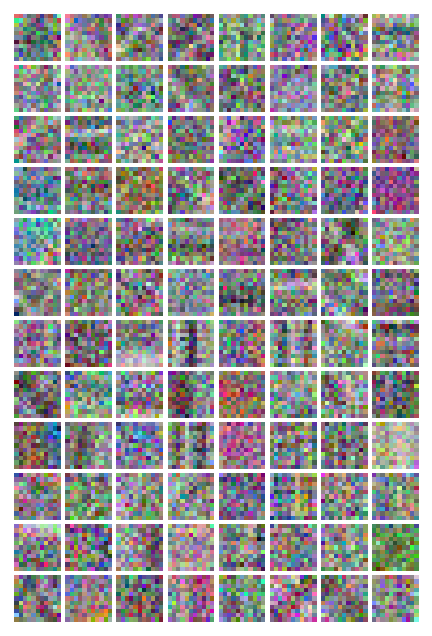

In [ ]:
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

w = torch.cat([model.conv11.weight, model.conv12.weight]).detach().cpu()

# scale by the min and max value of each kernel
low = w.amin(dim=(1, 2, 3), keepdim=True)
high = w.amax(dim=(1, 2, 3), keepdim=True)
w = (w-low)/(high-low+1e-8)

grid = make_grid(w, nrow=8, padding=1, pad_value=1)
plt.figure(figsize=(6, 8))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")